**Load packages and dataset**

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv("../data/GiveMeSomeCredit/cs-training.csv")

**Data pre-processing**

*Pre-filtering of features*

In [2]:
features = [col for col in df if (col not in ["SeriousDlqin2yrs", "Index", "NumberOfDependents", "age"])] # extract features except for target variable, index, and number of dependents and age (due to fairness)

df.head(10) # display dataframe for overview

,Index,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


*Treating missing values*

In [3]:
# Drop rows where values are NaN before splitting
print(df.isnull().sum()) # note: of the pre-filtered features, only MonthlyIncome has missing values
df_cleaned = df.dropna(subset=['SeriousDlqin2yrs']).fillna(-1) #set missing values in MonthlyIncome to -1

Index                                       0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


**Train / Test Split**

In [4]:
X = df_cleaned[features]
y = df_cleaned["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(   # 70:30 train:test data split
    X, y, test_size=0.3, random_state=42, stratify=y
)

**Decision Tree Binning**

*Definition of monotonic constraints*

In [5]:
monotonic_map = {    # mapping of features to their monotonic direction to enforce (see table with rationales in appendix of paper)
    "RevolvingUtilizationOfUnsecuredLines" : 1,
    "age" : -1,
    "NumberOfTime30-59DaysPastDueNotWorse" : 1,
    "DebtRatio" : 1,
    "MonthlyIncome" : -1,
    "NumberOfOpenCreditLinesAndLoans" : 1,
    "NumberOfTimes90DaysLate" : 1,
    "NumberRealEstateLoansOrLines" : 1,
    "NumberOfTime60-89DaysPastDueNotWorse" : 1
}

*Helper functions*

In [6]:
class BinClassCountError(Exception):
    """Raised when a bin contains zero instances of a class."""
    pass

def _calculate_woe_components(grouped_df):
    """
    Calculates Weight of Evidence (WoE) and Information Value (IV) components.
    """
    # Calculate percentages with small epsilon to avoid division by zero
    eps = 1e-6
    grouped_df['Pct Goods dec'] = grouped_df['Goods'] / (grouped_df['Goods'].sum() + eps)
    grouped_df['Pct Bads dec'] = grouped_df['Bads'] / (grouped_df['Bads'].sum() + eps)
    
    # Calculate Bad Rate and WoE
    grouped_df['Bad Rate'] = grouped_df['Bads'] / (grouped_df['Count'] + eps)
    grouped_df['WoE'] = np.log((grouped_df['Pct Goods dec'] + eps) / (grouped_df['Pct Bads dec'] + eps))
    
    return grouped_df

def _format_percentages(grouped_df, columns):
    """
    Converts decimal percentages to formatted percentage strings.
    """
    for col in columns:
        grouped_df[col] = (grouped_df[col] * 100).round(2).astype(str) + '%'
    return grouped_df

def _validate_bins(series, y, thresholds):
    """
    Validates that no bin has zero counts for either class.
    """
    bins = [-np.inf] + thresholds + [np.inf]
    binned = pd.cut(series, bins=bins)
    df_bin = pd.DataFrame({'bin': binned, 'target': y})
    bin_class_counts = pd.crosstab(df_bin['bin'], df_bin['target'])
    
    if (bin_class_counts == 0).any().any():
        raise BinClassCountError('There is a 0 count of either good or bad cases in at least one of the bins.')
    
# visualize    
def _plot_decision_tree(series, y, monotonic_cst, max_leaf_nodes, feature_name, feature_shortname='Number of times', filename="tree_30-59.pdf"):
    """
    Plots decision tree for visualization purposes.
    """
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=0.05,
        monotonic_cst=monotonic_cst
    )
    tree.fit(series.values.reshape(-1, 1), y)
    
    plot_tree(
        tree,
        feature_names=[feature_shortname],
        class_names=["No Default", "Default"],
        filled=True,
        rounded=True,
        impurity=True,
        proportion=True,
        precision=2,
        fontsize=11
    )
    plt.title(f"Decision Tree Binning for 'N30-59Late'")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


*Functions for table visualization of binnings*

In [7]:
def _binning_table_core(X, y, binned_col, feature):
    """
    Calculates IV and table overview including bin WoEs and Bad Rates for an already binned feature.
    """
    df = X.copy()
    df['target'] = y.values

    # Aggregate data by bins
    grouped = df.groupby(binned_col).agg(
        Count=(feature, 'count'),
        Goods=('target', lambda x: (x == 0).sum()),
        Bads=('target', lambda x: (x == 1).sum())
    ).reset_index()

    # Calculate WoE and IV metrics
    grouped = _calculate_woe_components(grouped)
    IV = ((grouped['Pct Goods dec'] - grouped['Pct Bads dec']) * grouped['WoE']).sum()
    print(f"Information Value (IV) for '{feature}': {IV:.4f}")

    # Format output percentages
    grouped = _format_percentages(grouped, ['Pct Goods dec', 'Pct Bads dec', 'Bad Rate'])
    grouped.rename(columns={
        'Pct Goods dec': 'Pct Goods',
        'Pct Bads dec': 'Pct Bads'
    }, inplace=True)
    
    # Round WoE values
    grouped['WoE'] = grouped['WoE'].round(2)

    # Return final column order
    return grouped[[binned_col, 'Count', 'Goods', 'Pct Goods', 'Bads', 'Pct Bads', 'Bad Rate', 'WoE']]

def binning_table_splitpoints(X, y, feature, splitpoints):
    """
    Bins a feature along given splitpoints.
    """
    X = X.copy()
    binned_col = f'{feature}_bin'
    bins = [-np.inf] + list(splitpoints) + [np.inf]
    labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins)-1)]
    X[binned_col] = pd.cut(X[feature], bins=bins, labels=labels, include_lowest=True)
    return _binning_table_core(X, y, binned_col, feature)

*Binning functions*

In [8]:
def _fit_tree_binning(series, y, monotonic_cst, max_leaf_nodes=None):
    """
    Fits decision tree for binning with monotonic constraints.
    Returns sorted thresholds excluding invalid values.
    """
    tree = DecisionTreeClassifier(
        criterion='entropy',
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=0.05,
        monotonic_cst=monotonic_cst
    )
    tree.fit(series.values.reshape(-1, 1), y)
    
    # Extract valid thresholds (excluding -2 which indicates no split)
    thresholds = sorted(t for t in tree.tree_.threshold if t != -2)
    return tree, thresholds

def _handle_zero_exception_binning(series, y, monotonic_cst, max_leaf_nodes):
    """
    Handle binning for features where zero needs special treatment.
    """
    mask_zero = series == 0
    zero_count = mask_zero.sum()
    
    # If enough zero instances, create separate bin
    if zero_count >= 5250:
        series_wo_zero = series[~mask_zero]
        y_wo_zero = y[~mask_zero]
        
        _, thresholds = _fit_tree_binning(series_wo_zero, y_wo_zero, monotonic_cst, max_leaf_nodes)
        return [0] + thresholds
    else:
        # Include zero values in regular binning
        _, thresholds = _fit_tree_binning(series, y, monotonic_cst, max_leaf_nodes)
        _validate_bins(series, y, thresholds)
        return thresholds


def tree_binning(series, y, monotonic_cst, feature_name=None, 
                 exclude_zero_monotonic_features=None, max_leaf_nodes=None): 
    """
    Defines bin splitpoint using tree binning, under monotonic constraints.
    Features with monotonicity exceptions for value 0 are handled specially.
    """
    if exclude_zero_monotonic_features is None:
        exclude_zero_monotonic_features = []

    # Handle features that need special treatment for zero values
    if feature_name in exclude_zero_monotonic_features:
        return _handle_zero_exception_binning(series, y, monotonic_cst, max_leaf_nodes)
    
    # Standard tree binning
    _, thresholds = _fit_tree_binning(series, y, monotonic_cst, max_leaf_nodes)
    _validate_bins(series, y, thresholds)
    
    # Special visualization for specific feature
    if feature_name == 'NumberOfTime30-59DaysPastDueNotWorse':
        _plot_decision_tree(series, y, monotonic_cst, max_leaf_nodes, feature_name)
    
    return thresholds

def tree_binning_with_missing(series, y, monotonic_cst, max_leaf_nodes=None, missing_value=-1):
    """
    Tree binning with explicit treatment of missing value, excepted from monotony.
    """
    # Filter out missing values for tree fitting
    mask_not_missing = series != missing_value
    series_not_missing = series[mask_not_missing]
    y_not_missing = y[mask_not_missing]

    # Perform tree binning on non-missing values
    _, thresholds = _fit_tree_binning(series_not_missing, y_not_missing, monotonic_cst, max_leaf_nodes)
    _validate_bins(series, y, thresholds)
    
    # Include missing value as separate bin boundary
    bins = thresholds.copy()
    bins.insert(0, missing_value)  
    return bins

*Perform binning*

RevolvingUtilizationOfUnsecuredLines split points: [np.float64(0.042629292234778404), np.float64(0.06654984131455421), np.float64(0.13183673471212387), np.float64(0.18418270349502563), np.float64(0.3008972406387329), np.float64(0.3956823796033859), np.float64(0.5003029108047485), np.float64(0.8545033931732178), np.float64(0.9891270399093628)]
Information Value (IV) for 'RevolvingUtilizationOfUnsecuredLines': 1.1104
      RevolvingUtilizationOfUnsecuredLines_bin  Count  Goods Pct Goods  Bads  \
0                 (-inf, 0.042629292234778404]  31298  30747    31.38%   551   
1  (0.042629292234778404, 0.06654984131455421]   7124   6998     7.14%   126   
2   (0.06654984131455421, 0.13183673471212387]  11397  11145    11.37%   252   
3   (0.13183673471212387, 0.18418270349502563]   5944   5781      5.9%   163   
4    (0.18418270349502563, 0.3008972406387329]   9265   8934     9.12%   331   
5     (0.3008972406387329, 0.3956823796033859]   5814   5502     5.62%   312   
6     (0.395682379603

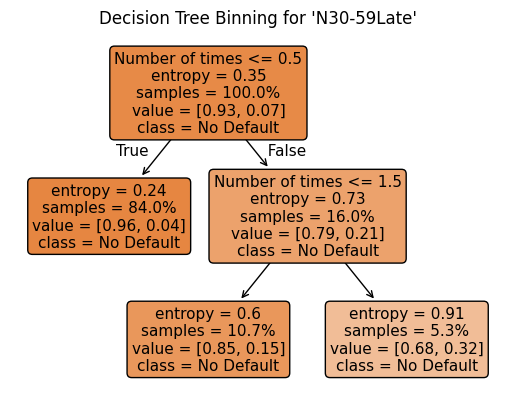

NumberOfTime30-59DaysPastDueNotWorse split points: [np.float64(0.5), np.float64(1.5)]
Information Value (IV) for 'NumberOfTime30-59DaysPastDueNotWorse': 0.7245
  NumberOfTime30-59DaysPastDueNotWorse_bin  Count  Goods Pct Goods  Bads  \
0                              (-inf, 0.5]  88178  84618    86.36%  3560   
1                               (0.5, 1.5]  11252   9592     9.79%  1660   
2                               (1.5, inf]   5570   3772     3.85%  1798   

  Pct Bads Bad Rate   WoE  
0   50.73%    4.04%  0.53  
1   23.65%   14.75% -0.88  
2   25.62%   32.28% -1.90  
DebtRatio split points: [np.float64(0.019949019886553288), np.float64(0.34570184350013733), np.float64(0.4233081787824631), np.float64(0.505493551492691)]
Information Value (IV) for 'DebtRatio': 0.0217
                                 DebtRatio_bin  Count  Goods Pct Goods  Bads  \
0                 (-inf, 0.019949019886553288]   9229   8742     8.92%   487   
1  (0.019949019886553288, 0.34570184350013733]  40561  38150 

In [9]:
binning_rules = {}
removals = []
exclude_zero_monotonic_features = ['NumberRealEstateLoansOrLines', 'NumberOfOpenCreditLinesAndLoans']

for col in features:
    if col not in monotonic_map:
        print(f'Warning: Feature {col} is not included in the mapping of monotonicity constraints and will thus be skipped.')
        continue
    
    monotonic_cst = monotonic_map[col]
    if monotonic_cst == 0:
        print(f'Warning: Feature {col} has uncertain properties with respect to monotonicity and will thus be excluded from scoring.')
        removals.append(col)
        continue
    
    # Apply appropriate binning method based on feature
    if col == 'MonthlyIncome':
        binning_rules[col] = tree_binning_with_missing(
            X_train[col], y_train, 
            monotonic_cst=[monotonic_cst], 
            missing_value=-1
        )
    else:
        binning_rules[col] = tree_binning(
            X_train[col], y_train, 
            feature_name=col, 
            exclude_zero_monotonic_features=exclude_zero_monotonic_features, 
            monotonic_cst=[monotonic_cst]
        )
    
    print(f"{col} split points: {binning_rules[col]}")
    print(binning_table_splitpoints(X_train, y_train, col, binning_rules[col]))

# Remove non-monotonic features

features = [col for col in features if col not in removals]

**WoE transformation**

In [10]:
def woe_table(series, y, thresholds):
    """
    Calculate WoE values for given thresholds, returns table of values.
    """
    bins = [-np.inf] + thresholds + [np.inf]
    binned = pd.cut(series, bins=bins)

    df_bin = pd.DataFrame({"bin": binned, "target": y})
    grouped = df_bin.groupby("bin", observed=True)["target"] 

    good = grouped.count() - grouped.sum()
    bad = grouped.sum()
    
    # Use epsilon to prevent division by 0 or log(0)
    eps = 1e-6
    good_calc = good + eps
    bad_calc = bad + eps

    # Calculate WoE
    woe = np.log(
        (good_calc / good_calc.sum()) /
        (bad_calc / bad_calc.sum())
    )

    # report original good and bad values
    table = pd.DataFrame({
        "bin": woe.index.astype(str),
        "good": good.values,
        "bad": bad.values,
        "woe": woe.values
    })

    # Optional: Warn if significant zero counts were present
    if (good < eps).any() or (bad < eps).any():
        print("Note: Near-zero counts detected, WoE values smoothed with epsilon correction")
    
    return table

In [11]:
woe_tables = {}
for col in features:
    if col not in binning_rules:
        print(f"Warning: Feature {col} is not in binning_rules.") 
    print(f'Split points for {col}: {binning_rules[col]}')
    woe_tables[col] = woe_table(
        X_train[col], y_train, binning_rules[col]
    )

Split points for RevolvingUtilizationOfUnsecuredLines: [np.float64(0.042629292234778404), np.float64(0.06654984131455421), np.float64(0.13183673471212387), np.float64(0.18418270349502563), np.float64(0.3008972406387329), np.float64(0.3956823796033859), np.float64(0.5003029108047485), np.float64(0.8545033931732178), np.float64(0.9891270399093628)]
Split points for NumberOfTime30-59DaysPastDueNotWorse: [np.float64(0.5), np.float64(1.5)]
Split points for DebtRatio: [np.float64(0.019949019886553288), np.float64(0.34570184350013733), np.float64(0.4233081787824631), np.float64(0.505493551492691)]
Split points for MonthlyIncome: [-1, np.float64(3332.5), np.float64(3920.5), np.float64(4621.5), np.float64(5563.5), np.float64(6550.5), np.float64(7656.5), np.float64(10284.0)]
Split points for NumberOfOpenCreditLinesAndLoans: [np.float64(14.5)]
Split points for NumberOfTimes90DaysLate: [np.float64(0.5)]
Split points for NumberRealEstateLoansOrLines: [0, np.float64(1.5), np.float64(2.5)]
Split poin

In [12]:
def apply_woe(series, woe_table, feature_thresholds):
    """
    Apply WoE transformation to a series using provided WoE table.
    """
    mapping = dict(zip(woe_table["bin"], woe_table["woe"]))
    bins = [-np.inf] + feature_thresholds + [np.inf]
    binned_series = pd.cut(series, bins=bins).astype(str)
    return binned_series.map(mapping)

X_train_woe = pd.DataFrame()
X_test_woe = pd.DataFrame()

for col in features:
    X_train_woe[col] = apply_woe(X_train[col], woe_tables[col], binning_rules[col])
    X_test_woe[col] = apply_woe(X_test[col], woe_tables[col], binning_rules[col])

**Feature Selection (Sequential Forward Selection)**

*Helper functions*

In [13]:
def calculate_vif(X, features):
    """Calculate variance inflation factor (VIF) for the given features."""
    X_sel = X[features]
    vif = [variance_inflation_factor(X_sel.values, i) for i in range(X_sel.shape[1])]
    return dict(zip(features, vif))

def _find_best_feature(X, y, candidate_features, currently_selected):
    """Find the best feature to add based on Average Precision Score."""
    scores = []
    for feature in candidate_features:
        model = LogisticRegression(solver="liblinear", random_state=42)
        features_to_test = currently_selected + [feature]
        model.fit(X[features_to_test], y)
        av_prec = average_precision_score(
            y,
            model.predict_proba(X[features_to_test])[:, 1]
        )
        scores.append((feature, av_prec))
    return max(scores, key=lambda x: x[1])

*Forward selection function*

In [14]:
def forward_selection(X, y, min_improvement=0.002, vif_cutoff=10):
    """
    Forward selection using Average Precision Score with VIF control.
    """
    selected_features = []
    remaining_features = list(X.columns)
    best_score = 0

    while remaining_features:
        # Find best candidate feature
        best_feature, candidate_score = _find_best_feature(
            X, y, remaining_features, selected_features
        )
        
        improvement = candidate_score - best_score
        print(f"Evaluating {best_feature}: Improvement {improvement:.4f}")
        
        # Check minimum improvement criterion
        if improvement < min_improvement:
            print(f"Stopping: Improvement {improvement:.4f} < min_improvement {min_improvement}")
            break
            
        # Add feature and update tracking
        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        best_score = candidate_score
        
        # VIF control for multicollinearity
        if len(selected_features) > 1:
            vif_dict = calculate_vif(X, selected_features)
            print(f"VIF values: {vif_dict}")
            
            high_vif_features = [f for f, vif in vif_dict.items() if vif > vif_cutoff]
            if high_vif_features:
                print(f"Removing features due to high VIF (> {vif_cutoff}): {high_vif_features}")
                for feature in high_vif_features:
                    selected_features.remove(feature)
                    # Note: These could be added back to remaining_features if desired
        
        print(f"Added: {best_feature} | AP: {best_score:.4f} | Improvement: {improvement:.4f}")
    
    return selected_features

*Perform forward selection*

In [15]:
selected_features = forward_selection(X_train_woe, y_train, min_improvement=0.002)

print("Final feature set:", sorted(selected_features))

Evaluating NumberOfTimes90DaysLate: Improvement 0.1896
Added: NumberOfTimes90DaysLate | AP: 0.1896 | Improvement: 0.1896
Evaluating RevolvingUtilizationOfUnsecuredLines: Improvement 0.0895
VIF values: {'NumberOfTimes90DaysLate': np.float64(1.1818804322893663), 'RevolvingUtilizationOfUnsecuredLines': np.float64(1.1818804322893528)}
Added: RevolvingUtilizationOfUnsecuredLines | AP: 0.2792 | Improvement: 0.0895
Evaluating NumberOfTime30-59DaysPastDueNotWorse: Improvement 0.0566
VIF values: {'NumberOfTimes90DaysLate': np.float64(1.2659752865053782), 'RevolvingUtilizationOfUnsecuredLines': np.float64(1.2720107756309325), 'NumberOfTime30-59DaysPastDueNotWorse': np.float64(1.24253081746328)}
Added: NumberOfTime30-59DaysPastDueNotWorse | AP: 0.3358 | Improvement: 0.0566
Evaluating NumberOfTime60-89DaysPastDueNotWorse: Improvement 0.0190
VIF values: {'NumberOfTimes90DaysLate': np.float64(1.3513727941255562), 'RevolvingUtilizationOfUnsecuredLines': np.float64(1.2933300962515146), 'NumberOfTime30

**Final Regression Model**

In [16]:
final_model = LogisticRegression(solver="liblinear")
final_model.fit(X_train_woe[selected_features], y_train)

test_auc = roc_auc_score(
    y_test,
    final_model.predict_proba(X_test_woe[selected_features])[:, 1]
)
test_prec = average_precision_score(
    y_test,
    final_model.predict_proba(X_test_woe[selected_features])[:, 1]
)

print("Results average precision-oriented model:")
print("Test AUC:", round(test_auc, 4))
print("Test av_prec:", round(test_prec, 4))

Results average precision-oriented model:
Test AUC: 0.8503
Test av_prec: 0.3737


**Scorecard Construction**

In [17]:
def build_scorecard(selected_features, model, woe_tables, pdo=20, base_score=600):
    """
    Build credit scorecard from logistic regression model and WoE tables.
    """
    # Calculate scaling factor
    B = pdo / np.log(2)
    
    scorecard = {}
    for i, feature in enumerate(selected_features):
        coefficient = model.coef_[0][i]
        table = woe_tables[feature].copy().round(3)
        
        # Calculate points (negative because higher WoE = lower risk = higher score)
        table["points"] = (-coefficient * table["woe"] * B).round(0).astype(int)
        scorecard[feature] = table[["bin", "woe", "points"]]

    
    return scorecard

def display_scorecard(scorecard):
    """
    Display scorecard in a formatted way.
    """
    for feature, table in scorecard.items():
        print(f"\nScorecard for {feature}")
        print(table)

In [18]:
scorecard = build_scorecard(selected_features, final_model, woe_tables, pdo=20)
display_scorecard(scorecard)


Scorecard for NumberOfTimes90DaysLate
           bin    woe  points
0  (-inf, 0.5]  0.396       6
1   (0.5, inf] -2.302     -36

Scorecard for RevolvingUtilizationOfUnsecuredLines
                bin    woe  points
0    (-inf, 0.0426]  1.386      27
1  (0.0426, 0.0665]  1.381      27
2   (0.0665, 0.132]  1.153      23
3    (0.132, 0.184]  0.932      18
4    (0.184, 0.301]  0.659      13
5    (0.301, 0.396]  0.234       5
6      (0.396, 0.5]  0.050       1
7      (0.5, 0.855] -0.603     -12
8    (0.855, 0.989] -1.190     -23
9      (0.989, inf] -1.447     -28

Scorecard for NumberOfTime30-59DaysPastDueNotWorse
           bin    woe  points
0  (-inf, 0.5]  0.532       8
1   (0.5, 1.5] -0.882     -13
2   (1.5, inf] -1.895     -28

Scorecard for NumberOfTime60-89DaysPastDueNotWorse
           bin    woe  points
0  (-inf, 0.5]  0.290       3
1   (0.5, inf] -2.081     -24

Scorecard for DebtRatio
               bin    woe  points
0   (-inf, 0.0199]  0.251       8
1  (0.0199, 0.346]  0.125  